# Exploring US Metro Housing Price Trends 
This notebook analyzes Zillow Housing Price Index (ZHVI) data across US metros. 
We'll explore trends, compare regions, and visualize growth patterns. 

## 1. Import Libraries 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

## 2. Load & Inspect Data

In [17]:
df = pd.read_csv("Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")

df.head()
df.columns[:10]
df['RegionName'].head(20)

0         United States
1          New York, NY
2       Los Angeles, CA
3           Chicago, IL
4            Dallas, TX
5           Houston, TX
6        Washington, DC
7      Philadelphia, PA
8             Miami, FL
9           Atlanta, GA
10           Boston, MA
11          Phoenix, AZ
12    San Francisco, CA
13        Riverside, CA
14          Detroit, MI
15          Seattle, WA
16      Minneapolis, MN
17        San Diego, CA
18            Tampa, FL
19           Denver, CO
Name: RegionName, dtype: str

## 3. Reshape Data (Wide to Long)

In [18]:
df_long = df.melt(
    id_vars =['RegionName'],
    var_name='Date',
    value_name='Zhvi'
)

df_long['Zhvi'] = pd.to_numeric(df_long['Zhvi'], errors='coerce')
df_long['Date'] = pd.to_datetime(df_long['Date'], format="%Y-%m-%d", errors='coerce')

df_long.head()

,RegionName,Date,Zhvi
0,United States,NaT,102001.0
1,"New York, NY",NaT,394913.0
2,"Los Angeles, CA",NaT,753899.0
3,"Chicago, IL",NaT,394463.0
4,"Dallas, TX",NaT,394514.0


## 4. Plot a Single Metro 

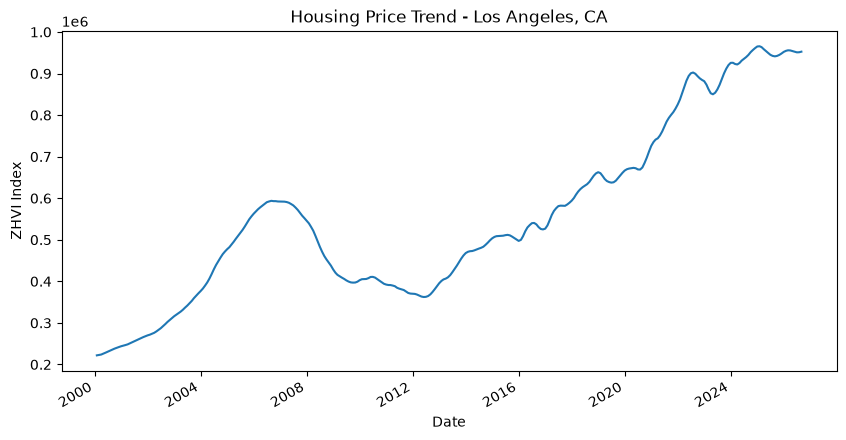

In [19]:
metro = "Los Angeles, CA"
df_metro = df_long[df_long['RegionName'] == metro].set_index('Date')

df_metro['Zhvi'].plot(figsize=(10,5), title=f"Housing Price Trend - {metro}")
plt.ylabel("ZHVI Index")
plt.show()

The housing pricing trend in Los Angeles shows distinct phases over the past 14 years:

- **2000-2004:** Prices started relatively low (just above 0.2 on the index) and remained fairly stable.
- **2004-2008:** A sharp increase occured (0.6 index), reflecting the housing boom leading up to the financial crisis.
- **2008-2012:** Prices declined steadily, mirroring the nationwide housing market crash and recession.
- **2012 onward:** The market recovered, with prices rising again in zigzag upward slope, showing periods of growth with small corrections. 


## 5. Compare Multiple Metros 

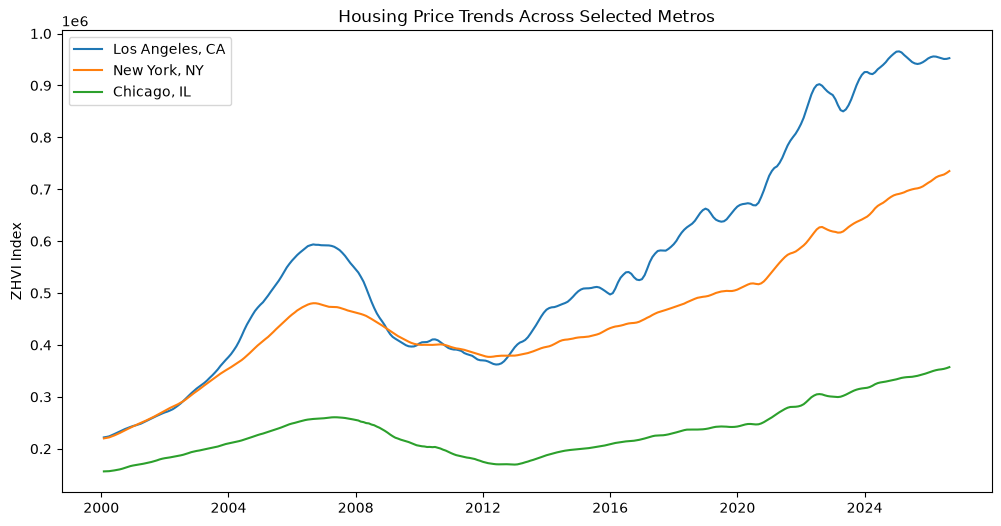

In [21]:
metros = ["Los Angeles, CA", "New York, NY", "Chicago, IL"]

plt.figure(figsize=(12,6))

for metro in metros:
    df_metro = df_long[df_long['RegionName'] == metro].groupby('Date')['Zhvi'].mean()
    plt.plot(df_metro.index, df_metro.values, label=metro)
    
plt.title("Housing Price Trends Across Selected Metros")
plt.ylabel("ZHVI Index")
plt.legend()
plt.show()

#### Los Angeles 

- **2000-2004:** Prices started relatively low (index between 0.2-0.3).
- **2004-2008:** Sharp rise, peaking around 0.6 - reflecting the housing boom.
- **2008-2012:** Steady decline during the crash.
- **2012 onward:** Strong zigzag recovery, steeper than New York and Chicago.

#### New York 

- **2000-2004:** Started low (index between 0.2-0.3).
- **2004-2008:** Rose steadily, but peak (~0.45) was below LA's (~0.6).
- **2008-2012:** Decline similar to LA, though less steep.
- **2012 onward:** Recovery slope is gentler than LA, showing slower growth.

#### Chicago 

- **2000-2004:** Began at a lower level than LA and NY (less than 0.2 index).
- **2004-2008:** Rose, but stayed below both LA and NY.
- **2008-2012:** Decline during the crash. 
- **2012 onward:** Recovery slope, but flatter than LA and NY, indicating weaker rebound. 

## 6. Growth Analysis 

In [22]:
growth = df_long.groupby("RegionName")['Zhvi'].apply(
    lambda x: (x.dropna().iloc[-1] - x.dropna().iloc[0]) / x.dropna().iloc[0] * 100
)

top_growth = growth.sort_values(ascending=False).head(10)
print(top_growth)

RegionName
San Jose, CA         286.709653
Jackson, WY          262.013176
United States        261.463794
Edwards, CO          230.171356
Heber, UT            191.762911
Santa Cruz, CA       190.774823
San Francisco, CA    184.311629
Kapaa, HI            158.004983
Kahului, HI          150.201398
Key West, FL         143.167557
Name: Zhvi, dtype: float64


## 7. Visualize growth

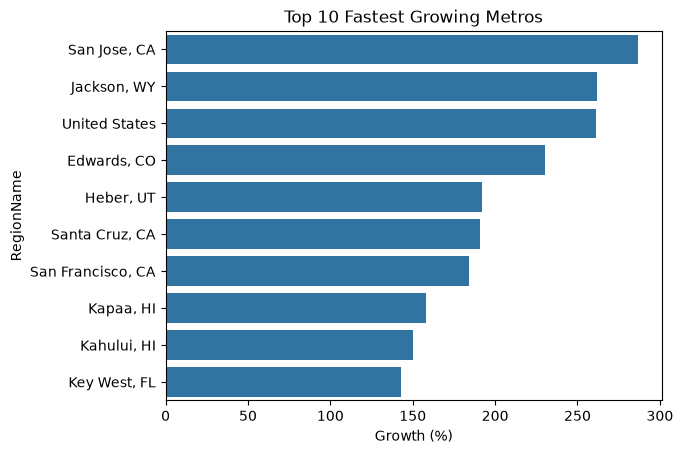

In [23]:
sns.barplot(x=top_growth.values, y=top_growth.index)
plt.title("Top 10 Fastest Growing Metros")
plt.xlabel("Growth (%)")
plt.show()

**Insights from the growth visualization:**

- **San Jose, CA** stands out with nearly **287% growth**, far above all other metros - a clear reflection of Silicon Valley's tech-driven housing demand. 
- **Jackson, WY** and **Edwards, CO** show very high growth as well, likely driven luxury housing and second-home demand in resort areas.
- The **United States overall** grew by about **261%**, which is high - so metros above this line (San Jose, Jackson, Santa Cruz, San Francisco) are outperforming the national average.
- **Coastal California metros** (San Jose, Santa Cruz, San Francisco) dominate the top tier, highlighting affordability pressures in the Bay Area.
- **Vacation destinations** like Kapaa, HI, Kahului, HI, and Key West, FL also appear in the top 10, showing strong demand for lifestyle and investment properties. 

## 8. Conclusion 

This analysis of Zillow housing price data highlights clear housing cycles and regional differences. 
- Los Angeles showed the sharpest boom before 2008, the steepest decline to 2012, and the strongest zigzag recovery afterward.
- New York followed a similar pattern but with lower peaks and a gentler rebound, while Chicago lagged behind both in growth.
- Growth analysis revealed that tech hubs like San Jose and San Francisco, along with lifestyle destinations such as Jackson, WY and Hawaii, far outpaced the national average.

Overall, the notebook demonstrates how data science can turn raw housing indices into meaningful insights, connecting visual patterns to real economic events and regional affordability challenges. 